# Financial Inclusion — XGBoost Model

---

**Ziel:** Vorhersage ob eine Person ein Bankkonto besitzt (`bank_account`: 0 = Nein, 1 = Ja)

**Datengrundlage:**
- Features: `data/features_encoded_train.csv` (aus `Train_Encoding.ipynb`)
- Test-Predictions: `data/features_encoded_TEST.csv` (aus `Model_Encoding.ipynb`)

**Warum XGBoost?**
- Unser Baseline (Logistic Regression) ist ein lineares Modell — es kann nur lineare Zusammenhänge lernen
- XGBoost ist ein **Gradient Boosting** Algorithmus: er baut viele schwache Entscheidungsbäume sequenziell auf, wobei jeder Baum die Fehler des vorherigen korrigiert
- Besonders gut bei tabellarischen Daten mit gemischten Feature-Typen
- Robust gegenüber Ausreißern und Imbalanced Classes


---
### Step 0 — Imports

Wir laden:
- **pandas / numpy** — Datenverarbeitung
- **xgboost** — unser Modell
- **sklearn** — Train/Val-Split, Metriken, Confusion Matrix
- **matplotlib / seaborn** — Visualisierungen

In [51]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

print('Alle Imports erfolgreich.')

Alle Imports erfolgreich.


---
### Step 1 — Daten laden & aufteilen (X / y)

Wir laden `features_encoded_train.csv` und trennen:
- **X** — alle Feature-Spalten (Eingabe für das Modell)
- **y** — die Zielspalte `target_bank_account` (was das Modell vorhersagen soll)

Die Zielverteilung zeigt uns ob die Klassen **unbalanced** sind — das beeinflusst wie wir XGBoost konfigurieren.

In [52]:
df = pd.read_csv('data/features_encoded_train.csv')

X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

print(f'Zeilen: {len(df):,}')
print(f'Features (X): {X.shape[1]} Spalten')
print(f'\nZielverteilung (y):')
print(f'  Kein Konto (0): {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'  Konto     (1): {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')

Zeilen: 23,524
Features (X): 17 Spalten

Zielverteilung (y):
  Kein Konto (0): 20,212  (85.9%)
  Konto     (1): 3,312  (14.1%)


---
### Step 2 — Train/Validation-Split

Wir teilen die Daten in **80% Training** und **20% Validation** auf.

- Das Modell lernt nur auf den Trainingsdaten
- Die Validation-Daten sind "unsichtbar" während des Trainings — damit messen wir wie gut das Modell auf neuen Daten funktioniert
- `stratify=y` stellt sicher dass die Klassenverteilung (85/15) in beiden Splits erhalten bleibt

In [53]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Trainingsdaten  : {len(X_train):,} Zeilen ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validierungsdaten: {len(X_val):,} Zeilen ({len(X_val)/len(X)*100:.0f}%)')
print(f'\nKlassenverteilung Training:')
print(f'  Kein Konto (0): {(y_train == 0).sum():,}  ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Konto     (1): {(y_train == 1).sum():,}  ({(y_train == 1).mean()*100:.1f}%)')

Trainingsdaten  : 18,819 Zeilen (80%)
Validierungsdaten: 4,705 Zeilen (20%)

Klassenverteilung Training:
  Kein Konto (0): 16,169  (85.9%)
  Konto     (1): 2,650  (14.1%)


---
### Step 3 — XGBoost Baseline trainieren

Wir trainieren ein erstes Modell mit wenigen wichtigen Parametern:

| Parameter | Wert | Erklärung |
|---|---|---|
| `n_estimators` | 300 | Anzahl der Bäume die gebaut werden |
| `max_depth` | 4 | Wie tief jeder Baum wachsen darf — verhindert Overfitting |
| `learning_rate` | 0.05 | Wie stark jeder neue Baum korrigiert — kleiner = stabiler |
| `scale_pos_weight` | **natürlich × 1.5** | Natürliches Verhältnis (85/15) × 1.5 Boost → Financial Inclusion: False Negatives stärker bestrafen |
| `eval_metric` | `auc` | XGBoost überwacht intern AUC |

> **Financial Inclusion:** `scale_pos_weight` wird über das natürliche Klassengewicht hinaus erhöht — das Modell lernt von Anfang an False Negatives (ausgeschlossene Berechtigte) stärker zu vermeiden.

In [54]:
# Natürliches Klassengewicht × 1.5 für Financial Inclusion
# → Modell bestraft False Negatives (Berechtigte die ausgeschlossen werden) stärker
natural_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight = natural_weight * 1.5
print(f'Natürliches Gewicht : {natural_weight:.2f}')
print(f'Financial Inclusion : {scale_pos_weight:.2f}  (× 1.5)')

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('Training abgeschlossen.')

Natürliches Gewicht : 6.10
Financial Inclusion : 9.15  (× 1.5)
Training abgeschlossen.


---
### Step 4 — Evaluation

Wir messen die Modellqualität mit zwei Methoden:

1. **ROC-AUC Score** — Hauptmetrik des Wettbewerbs. Misst wie gut das Modell zwischen Konto/kein Konto unterscheidet. 1.0 = perfekt, 0.5 = Zufall.
2. **Confusion Matrix** — zeigt wie viele Fälle korrekt/falsch klassifiziert wurden (True Positive, False Positive, etc.)

ROC-AUC (Validation): 0.8738

                precision    recall  f1-score   support

Kein Konto (0)       0.97      0.71      0.82      4043
     Konto (1)       0.33      0.86      0.47       662

      accuracy                           0.73      4705
     macro avg       0.65      0.79      0.65      4705
  weighted avg       0.88      0.73      0.77      4705



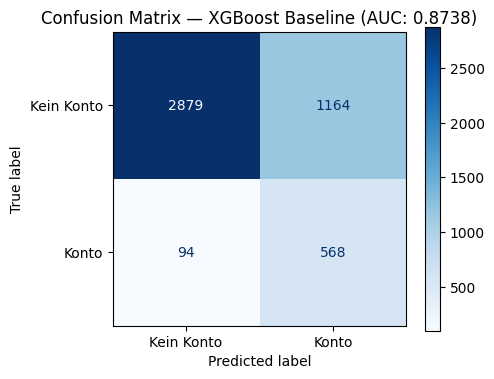

In [55]:
# Wahrscheinlichkeiten und binäre Predictions
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred  = model.predict(X_val)

# ROC-AUC
auc = roc_auc_score(y_val, y_val_proba)
print(f'ROC-AUC (Validation): {auc:.4f}')
print()

# Classification Report
print(classification_report(y_val, y_val_pred, target_names=['Kein Konto (0)', 'Konto (1)']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=['Kein Konto', 'Konto'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix — XGBoost Baseline (AUC: {auc:.4f})')
plt.tight_layout()
plt.show()

---
### Step 5 — Feature Importance

XGBoost kann uns zeigen welche Features am meisten zur Vorhersage beigetragen haben.

Wir nutzen `weight` als Importance-Typ — er zählt wie oft ein Feature über alle Bäume hinweg für einen Split verwendet wurde. Je höher, desto relevanter.

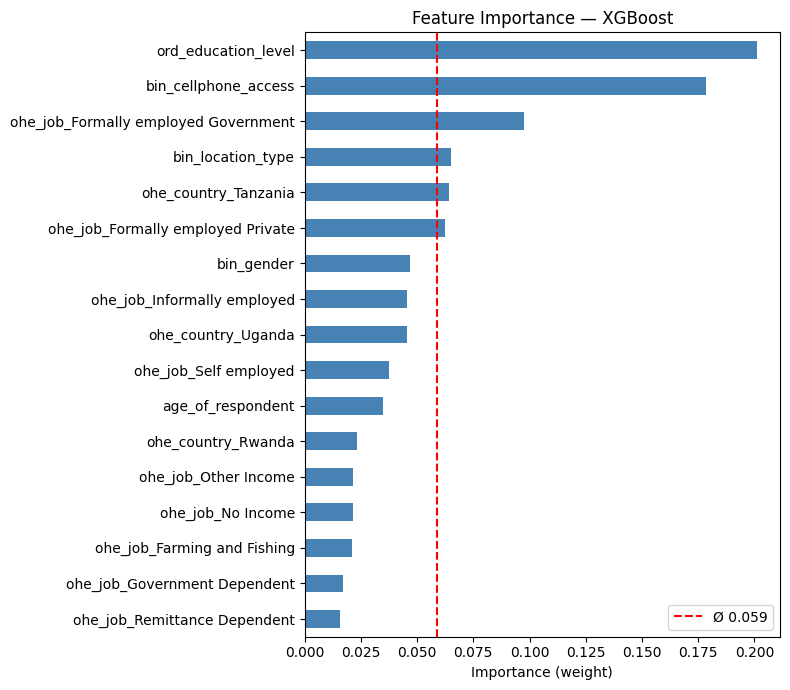


Top 5 wichtigste Features:
  ord_education_level                           0.2013
  bin_cellphone_access                          0.1785
  ohe_job_Formally employed Government          0.0978
  bin_location_type                             0.0651
  ohe_country_Tanzania                          0.0640


In [56]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — XGBoost')
ax.set_xlabel('Importance (weight)')
ax.axvline(importance.mean(), color='red', linestyle='--', label=f'Ø {importance.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 wichtigste Features:')
for feat, val in importance.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<45} {val:.4f}')

---
### Step 6 — Hyperparameter Tuning

Wir suchen bessere Parameter mit `GridSearchCV` — es testet systematisch alle Kombinationen und wählt die beste via Cross-Validation.

Wir tunen die drei einflussreichsten Parameter:

| Parameter | Getestete Werte | Wirkung |
|---|---|---|
| `n_estimators` | 200, 400 | Mehr Bäume = mehr Lernkapazität |
| `max_depth` | 3, 4, 5 | Tiefere Bäume = komplexere Muster, aber Overfitting-Risiko |
| `learning_rate` | 0.01, 0.05, 0.1 | Kleiner = stabiler aber langsamer |

> Das Grid hat 2 × 3 × 3 = **18 Kombinationen** × 3 Folds = 54 Fits — dauert ca. 1–2 Minuten.

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

base_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'\nBeste Parameter : {grid_search.best_params_}')
print(f'Bester CV-Recall: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Beste Parameter : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Bester CV-Recall: 0.9053


In [58]:
# Bestes Modell auf Validation evaluieren
best_model = grid_search.best_estimator_

y_val_proba_tuned = best_model.predict_proba(X_val)[:, 1]
y_val_pred_tuned  = best_model.predict(X_val)

auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)

print(f'ROC-AUC Baseline : {auc:.4f}')
print(f'ROC-AUC Tuned    : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')

ROC-AUC Baseline : 0.8738
ROC-AUC Tuned    : 0.8453  (-0.0284)


---
### Step 6b — Erweitertes Tuning mit RandomizedSearchCV

Wir erweitern den Parameterraum deutlich und nutzen `RandomizedSearchCV` — es zieht zufällig Kombinationen aus dem Grid statt alle zu testen. So können wir viel mehr Parameter abdecken bei ähnlicher Laufzeit.

Neue Parameter gegenüber Step 6:

| Parameter | Wirkung |
|---|---|
| `subsample` | Anteil der Trainingszeilen pro Baum — reduziert Overfitting |
| `colsample_bytree` | Anteil der Features pro Baum — wie Random Forest Idee |
| `min_child_weight` | Mindestgewicht in einem Blatt — verhindert zu spezifische Splits |
| `gamma` | Mindest-Informationsgewinn für einen Split — zusätzliche Regularisierung |

> 50 zufällige Kombinationen × 3 Folds = 150 Fits — ca. 2–3 Minuten.

In [59]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [200, 300, 400, 500, 600],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.3],
}

rand_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=RANDOM_STATE,
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='recall',       # Financial Inclusion: Recall maximieren
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)

rand_search.fit(X_train, y_train)

print(f'\nBeste Parameter:')
for k, v in rand_search.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\nBester CV-Recall (RandomizedSearch): {rand_search.best_score_:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Beste Parameter:
  subsample             : 0.9
  n_estimators          : 300
  min_child_weight      : 5
  max_depth             : 4
  learning_rate         : 0.01
  gamma                 : 0.3
  colsample_bytree      : 1.0

Bester CV-Recall (RandomizedSearch): 0.8577


In [60]:
# Vergleich aller drei Modelle
best_model_v2 = rand_search.best_estimator_

y_val_proba_v2 = best_model_v2.predict_proba(X_val)[:, 1]
auc_v2 = roc_auc_score(y_val, y_val_proba_v2)

print(f'ROC-AUC Baseline (Step 3)   : {auc:.4f}')
print(f'ROC-AUC GridSearch (Step 6) : {auc_tuned:.4f}  ({auc_tuned - auc:+.4f})')
print(f'ROC-AUC RandomizedSearch    : {auc_v2:.4f}  ({auc_v2 - auc:+.4f})')
print()
print(f'Bestes Modell: {"RandomizedSearch" if auc_v2 >= auc_tuned else "GridSearch"}')

ROC-AUC Baseline (Step 3)   : 0.8738
ROC-AUC GridSearch (Step 6) : 0.8453  (-0.0284)
ROC-AUC RandomizedSearch    : 0.8644  (-0.0094)

Bestes Modell: RandomizedSearch


---
### Step 6c — Threshold Tuning für Financial Inclusion

**Ziel:** Niemanden ausschließen der eigentlich ein Konto bekommen sollte → **Recall maximieren**, False Negatives minimieren.

Standardmäßig klassifiziert das Modell ab Wahrscheinlichkeit `0.5` als "Konto". Wir senken diesen Schwellwert — dadurch wird das Modell großzügiger und schließt weniger Berechtigte aus.

Wir plotten den Trade-off zwischen **Recall** und **Precision** über alle möglichen Schwellwerte und wählen den Punkt wo Recall hoch ist ohne Precision komplett zu opfern.

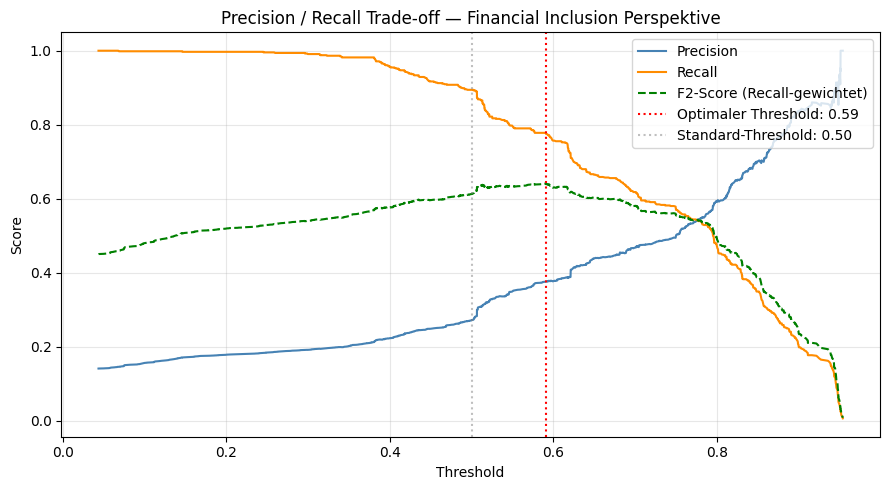

Optimaler Threshold (F2): 0.59
  Precision : 0.376
  Recall    : 0.778
  F2-Score  : 0.641


In [61]:
from sklearn.metrics import precision_recall_curve, f1_score

# Bestes Modell aus Step 6b verwenden
proba = y_val_proba_v2

precisions, recalls, thresholds = precision_recall_curve(y_val, proba)

# F2-Score berechnen — gewichtet Recall doppelt so stark wie Precision
# ideal für Financial Inclusion: wir tolerieren mehr False Positives um False Negatives zu vermeiden
f2_scores = (1 + 2**2) * (precisions * recalls) / ((2**2 * precisions) + recalls + 1e-9)
best_idx  = f2_scores.argmax()
best_threshold = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='darkorange')
ax.plot(thresholds, f2_scores[:-1],  label='F2-Score (Recall-gewichtet)', color='green', linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', label=f'Optimaler Threshold: {best_threshold:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Standard-Threshold: 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall Trade-off — Financial Inclusion Perspektive')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimaler Threshold (F2): {best_threshold:.2f}')
print(f'  Precision : {precisions[best_idx]:.3f}')
print(f'  Recall    : {recalls[best_idx]:.3f}')
print(f'  F2-Score  : {f2_scores[best_idx]:.3f}')

=== Standard Threshold (0.50) ===
              precision    recall  f1-score   support

  Kein Konto       0.97      0.61      0.75      4043
       Konto       0.27      0.89      0.42       662

    accuracy                           0.65      4705
   macro avg       0.62      0.75      0.58      4705
weighted avg       0.87      0.65      0.70      4705

=== Optimierter Threshold (0.59) — Financial Inclusion ===
              precision    recall  f1-score   support

  Kein Konto       0.96      0.79      0.86      4043
       Konto       0.38      0.78      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.81      4705



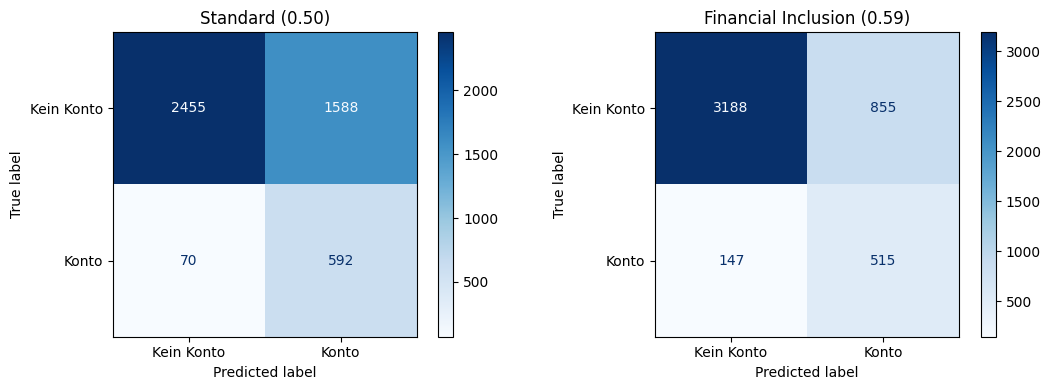

In [62]:
# Vergleich: Standard-Threshold (0.5) vs. optimierter Threshold
y_pred_standard = (proba >= 0.5).astype(int)
y_pred_tuned    = (proba >= best_threshold).astype(int)

print('=== Standard Threshold (0.50) ===')
print(classification_report(y_val, y_pred_standard, target_names=['Kein Konto', 'Konto']))

print(f'=== Optimierter Threshold ({best_threshold:.2f}) — Financial Inclusion ===')
print(classification_report(y_val, y_pred_tuned, target_names=['Kein Konto', 'Konto']))

# Confusion Matrix nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes,
    [y_pred_standard, y_pred_tuned],
    [f'Standard (0.50)', f'Financial Inclusion ({best_threshold:.2f})']):
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds,
        display_labels=['Kein Konto', 'Konto'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
### Step 7 — Predictions auf Test-Daten

Wir generieren die finalen Predictions auf den echten Test-Daten und speichern sie als DataFrame — **noch keine CSV**, da wir später alle Modelle vergleichen und dann gemeinsam entscheiden welches wir einreichen.

Vorgehen:
1. Bestes Modell auf **allen** Trainingsdaten neu trainieren (kein 80/20-Split mehr — mehr Daten = besser)
2. Optimierten Threshold aus Step 6c anwenden
3. Predictions als DataFrame festhalten

In [63]:
# Bestes Modell auf ALLEN Trainingsdaten neu trainieren
final_model = rand_search.best_estimator_.__class__(**rand_search.best_params_,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
)
final_model.fit(X, y)
print('Finales Modell auf allen Trainingsdaten trainiert.')

# Test-Daten laden und Predictions generieren
X_test = pd.read_csv('data/features_encoded_TEST.csv')
test_proba = final_model.predict_proba(X_test)[:, 1]

# Optimierten Threshold aus Step 6c anwenden
test_pred = (test_proba >= best_threshold).astype(int)

# IDs aufbauen: uniqueid + ' x ' + country
train_raw = pd.read_csv('data/Train.csv')[['uniqueid', 'country']]
test_raw  = pd.read_csv('data/Test.csv')[['uniqueid', 'country']]

train_raw['unique_id'] = train_raw['uniqueid'] + ' x ' + train_raw['country']
test_raw['unique_id']  = test_raw['uniqueid']  + ' x ' + test_raw['country']

# Predictions für Train- und Test-Rows
train_proba_final = final_model.predict_proba(X)[:, 1]
train_pred_final  = (train_proba_final >= best_threshold).astype(int)

df_preds_xgboost = pd.concat([
    pd.DataFrame({'unique_id': train_raw['unique_id'].values, 'bank_account': train_proba_final}),
    pd.DataFrame({'unique_id': test_raw['unique_id'].values,  'bank_account': test_proba}),
], ignore_index=True)

print(f'\nPredictions bereit: {len(df_preds_xgboost):,} Zeilen')
print(f'Threshold          : {best_threshold:.2f}')
print(f'Anteil "Konto=1"   : {test_pred.mean()*100:.1f}% der Test-Personen')
df_preds_xgboost.head(3)

Finales Modell auf allen Trainingsdaten trainiert.

Predictions bereit: 33,610 Zeilen
Threshold          : 0.59
Anteil "Konto=1"   : 28.5% der Test-Personen


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.643758
1,uniqueid_2 x Kenya,0.517567
2,uniqueid_3 x Kenya,0.887957


---
### Step 8 — Evaluation des finalen Modells

Da das finale Modell auf **allen** Trainingsdaten trainiert wurde, nutzen wir **Cross-Validation** für eine ehrliche Einschätzung der Performance — so gibt es keine Datenlecks.

Zusätzlich zeigen wir das komplette Ergebnis mit dem optimierten Threshold aus Step 6c.

=== Cross-Validation (5-Fold) — Finales Modell ===
ROC-AUC : 0.8561  ± 0.0076
Recall  : 0.8629  ± 0.0080

=== Validation-Set Evaluation (Threshold: 0.59) ===
ROC-AUC: 0.8719

              precision    recall  f1-score   support

  Kein Konto       0.96      0.79      0.87      4043
       Konto       0.38      0.77      0.51       662

    accuracy                           0.79      4705
   macro avg       0.67      0.78      0.69      4705
weighted avg       0.87      0.79      0.82      4705



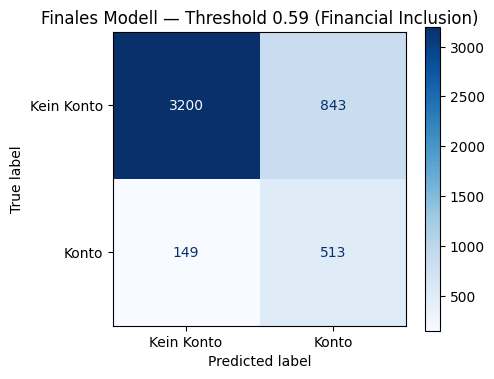

In [64]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# AUC und Recall via Cross-Validation
cv_auc    = cross_val_score(final_model, X, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_recall = cross_val_score(final_model, X, y, cv=cv, scoring='recall',   n_jobs=-1)

print('=== Cross-Validation (5-Fold) — Finales Modell ===')
print(f'ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}')
print(f'Recall  : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}')
print()

# Validation-Set Evaluation mit optimiertem Threshold
y_final_proba = final_model.predict_proba(X_val)[:, 1]
y_final_pred  = (y_final_proba >= best_threshold).astype(int)

auc_final = roc_auc_score(y_val, y_final_proba)

print(f'=== Validation-Set Evaluation (Threshold: {best_threshold:.2f}) ===')
print(f'ROC-AUC: {auc_final:.4f}')
print()
print(classification_report(y_val, y_final_pred, target_names=['Kein Konto', 'Konto']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_final_pred,
    display_labels=['Kein Konto', 'Konto'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Finales Modell — Threshold {best_threshold:.2f} (Financial Inclusion)')
plt.tight_layout()
plt.show()